# Basic regressor models to predict SoH

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
data = pd.read_csv('../dataset/processed/battery_health_dataset.csv')

# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# scaler = StandardScaler()
# data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'SoH']] = scaler.fit_transform(
#     data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'SoH']]
# )

X = data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']]
y = data['SoH']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# GridSearchCV Hyperparameter Tuning
rf_params = {
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 100
}

dt_params = {
    'max_depth': None,
    'min_samples_leaf': 4,
    'min_samples_split': 2
}

xgb_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 9,
    'n_estimators': 200,
    'subsample': 0.7
}

In [44]:
# Initialize the model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVR, OneClassSVM
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


models = {
    'Linear Regression': LinearRegression(),
    'SVM': SVR(),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42, **rf_params),
    'Decision Tree': DecisionTreeRegressor(random_state=42, **dt_params),
    'XGBoost': XGBRegressor(random_state=42, **xgb_params),
}

In [45]:
results = {}
y_preds = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = root_mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    results[model_name] = {
        'Train_MAE': train_mae, 'Test_MAE': test_mae,
        'Train_RMSE': train_rmse, 'Test_RMSE': test_rmse,
        'Train_R²': train_r2, 'Test_R²': test_r2
    }
    y_preds[model_name] = y_test_pred

In [46]:

print(f"{'Model':<20}{'Train MAE':<12}{'Test MAE':<12}{'Train RMSE':<12}{'Test RMSE':<12}{'Train R²':<12}{'Test R²':<12}")
print("="*90)

for model_name, metrics in results.items():
    print(f"{model_name:<20}{metrics['Train_MAE']:<12.4f}{metrics['Test_MAE']:<12.4f}"
          f"{metrics['Train_RMSE']:<12.4f}{metrics['Test_RMSE']:<12.4f}"
          f"{metrics['Train_R²']:<12.4f}{metrics['Test_R²']:<12.4f}")

Model               Train MAE   Test MAE    Train RMSE  Test RMSE   Train R²    Test R²     
Linear Regression   0.6097      0.6152      0.7428      0.7428      0.4531      0.4534      
SVM                 0.5471      0.5571      0.7407      0.7407      0.4603      0.4564      
KNN                 0.3404      0.4307      0.5933      0.5933      0.7816      0.6513      
Random Forest       0.0264      0.0683      0.1988      0.1988      0.9949      0.9608      
Decision Tree       0.0354      0.0697      0.2343      0.2343      0.9857      0.9456      
XGBoost             0.0334      0.0735      0.1674      0.1674      0.9970      0.9722      


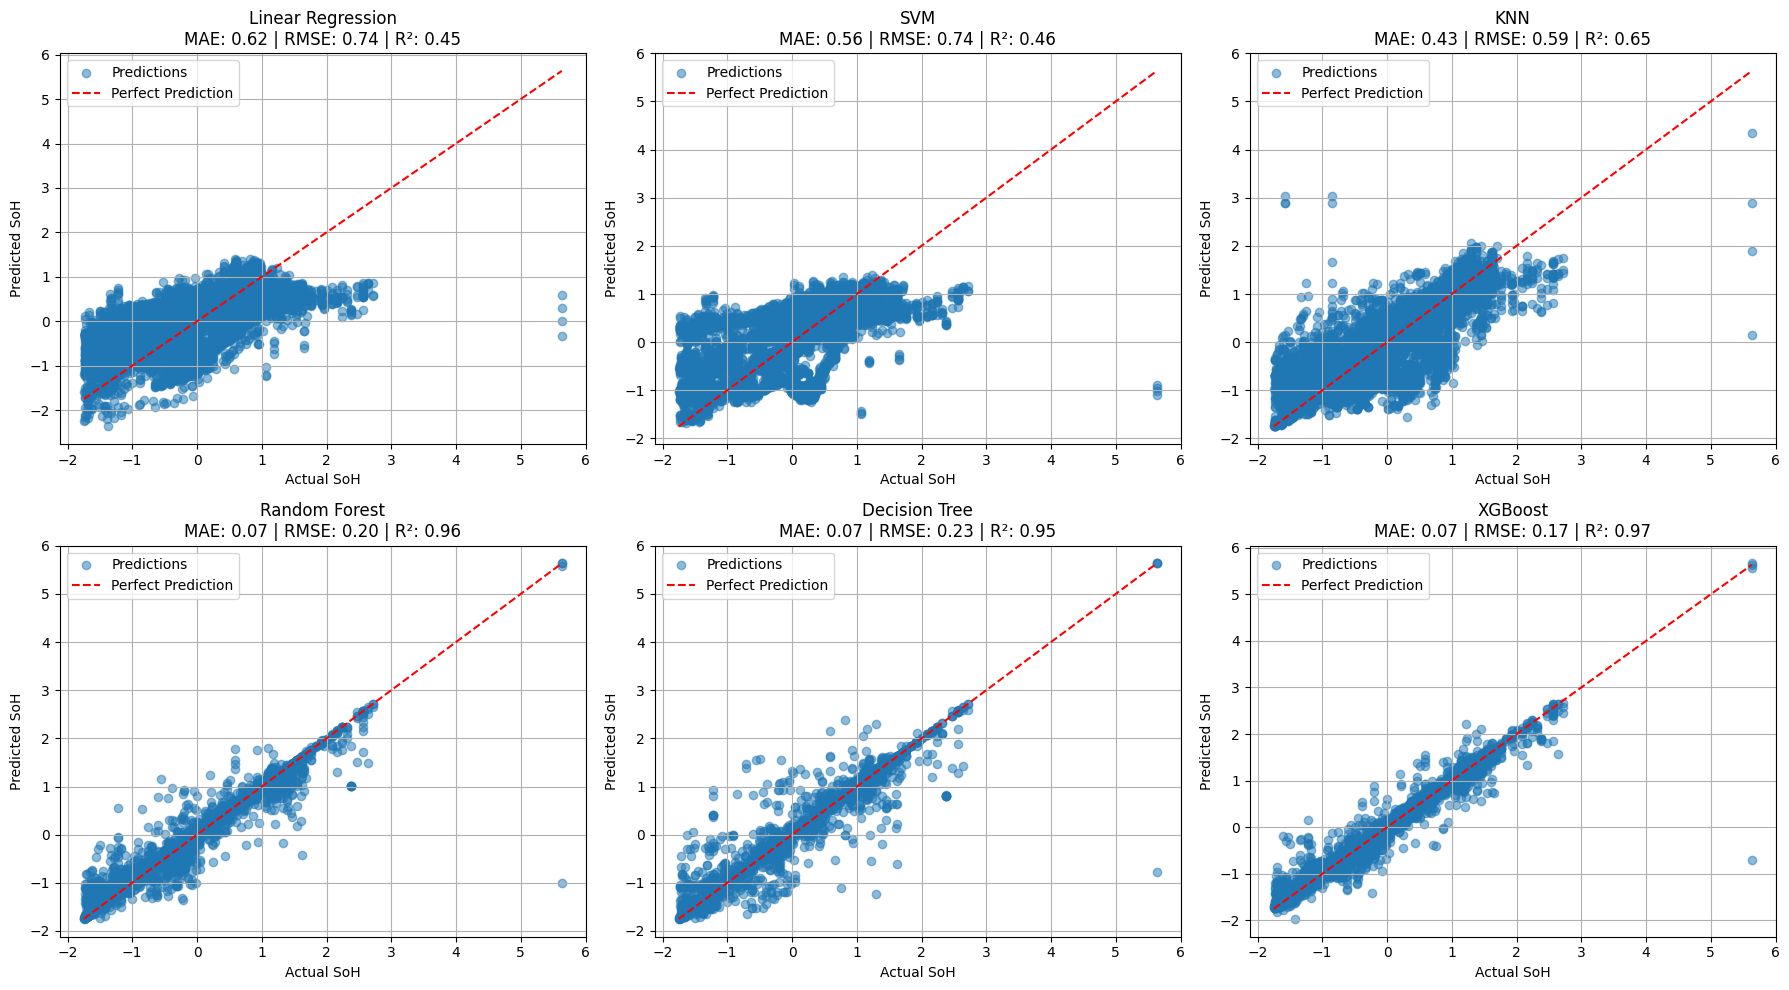

In [47]:
# Visualization: Actual vs Predicted SoH
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (model_name, y_test_pred) in enumerate(y_preds.items()):
    ax = axes[i]
    ax.scatter(y_test, y_test_pred, alpha=0.5, label='Predictions')
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
            color='red', linestyle='--', label='Perfect Prediction')

    ax.set_xlabel('Actual SoH')
    ax.set_ylabel('Predicted SoH')
    ax.set_title(f'{model_name}\nMAE: {results[model_name]["Test_MAE"]:.2f} | '
                 f'RMSE: {results[model_name]["Test_RMSE"]:.2f} | R²: {results[model_name]["Test_R²"]:.2f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

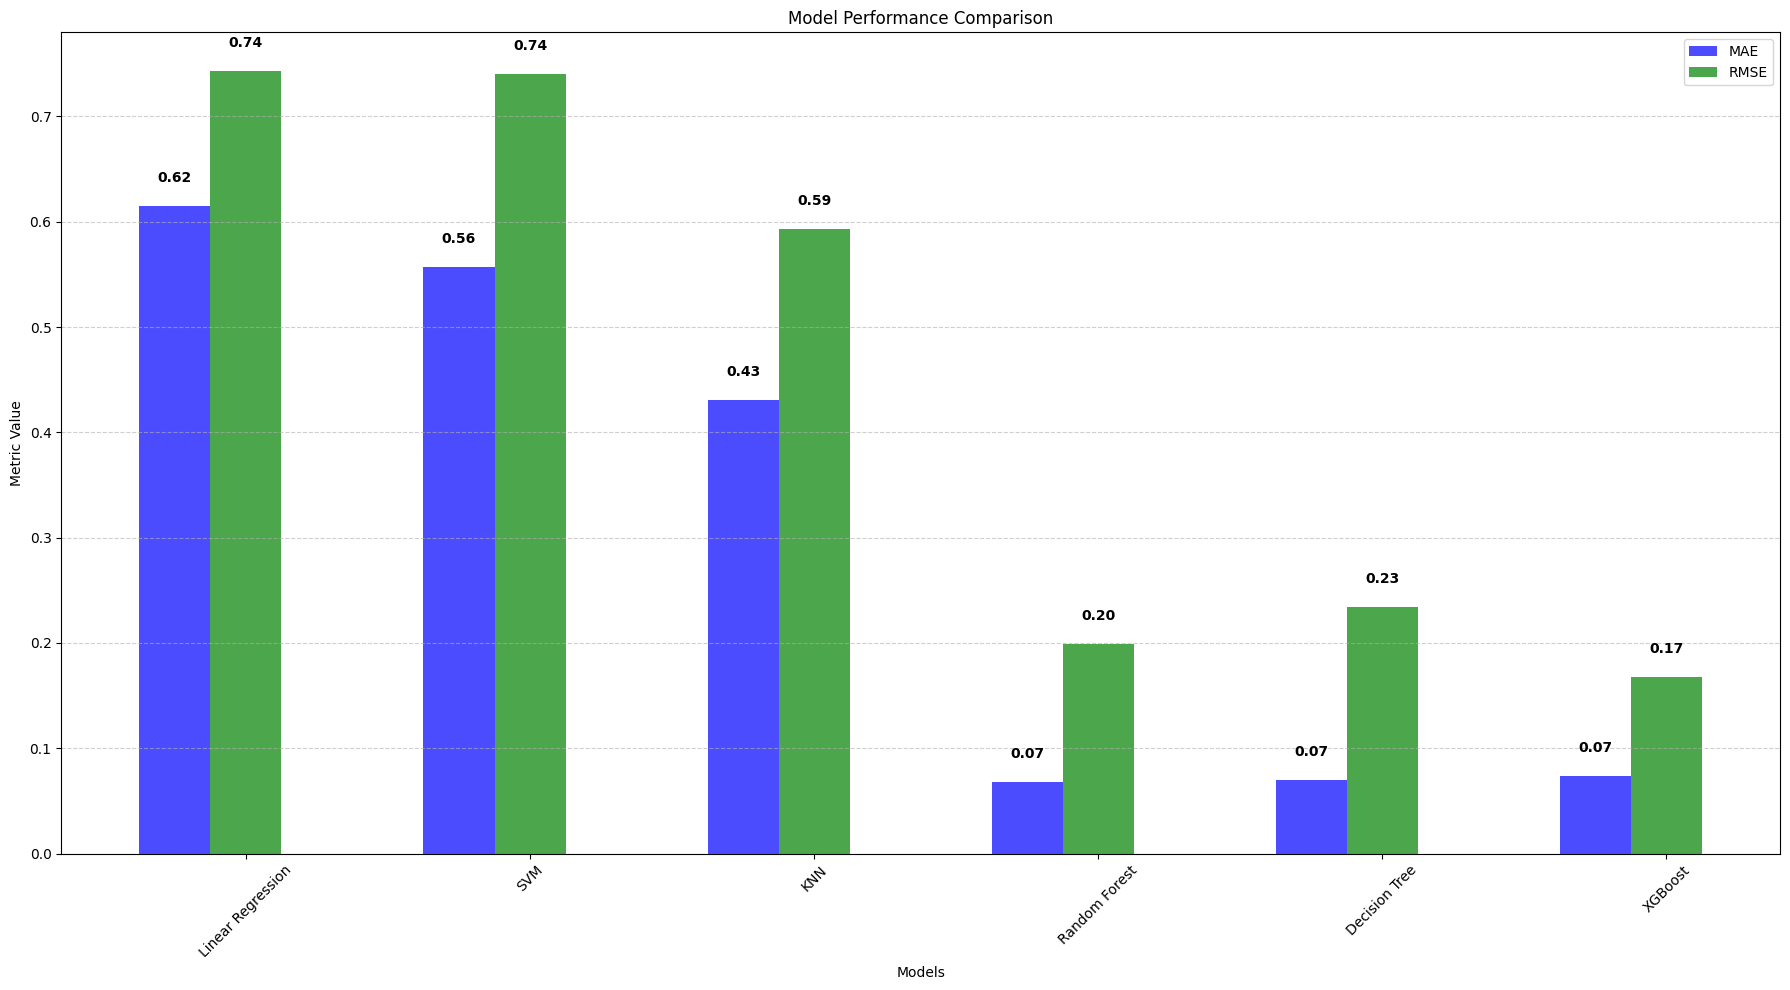

In [49]:
model_names = list(results.keys())
mae_values = [results[m]["Test_MAE"] for m in model_names]
rmse_values = [results[m]["Test_RMSE"] for m in model_names]
r2_values = [results[m]["Test_R²"] for m in model_names]

fig, ax = plt.subplots(figsize=(18, 10))
bar_width = 0.25
index = np.arange(len(model_names))

bars_mae = ax.bar(index, mae_values, bar_width, label='MAE', color='blue', alpha=0.7)
bars_rmse = ax.bar(index + bar_width, rmse_values, bar_width, label='RMSE', color='green', alpha=0.7)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

add_labels(bars_mae)
add_labels(bars_rmse)

ax.set_xlabel("Models")
ax.set_ylabel("Metric Value")
ax.set_title("Model Performance Comparison")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()